# CLAHE (Contrast-Limited Adaptive Histogram Equalization) — GPU-first (cuCIM/CuPy) with CPU Fallback

**Goal:** Apply CLAHE to 2D images or 3D stacks using the GPU when available, with a simple interactive preview for tuning and a robust full-dataset batch processor.

**Key ideas**
- Uses `cucim.skimage.exposure.equalize_adapthist` on **GPU** (CuPy arrays).
- Falls back to `skimage.exposure.equalize_adapthist` on **CPU** if GPU libs are missing.
- Handles **uint8/uint16/float** inputs; can return **original dtype** if `preserve_dtype=True`.
- Supports **per-slice** CLAHE for 3D stacks (Z-slabbing to fit 16 GB VRAM).

**Typical tuning**
- `kernel_size` (tile size): 32–128 for 2D; for 3D, often per-slice is faster/leaner.
- `clip_limit`: 0.005–0.03 (higher → more contrast, but can amplify noise).
- `nbins`: 256 (8-bit) or 1024–4096 (12–16-bit).


In [1]:
# Imports are organized to keep GPU/CPU paths clean and explicit
from __future__ import annotations
import os, math, gc
from pathlib import Path
from typing import Optional, Sequence, Tuple

import numpy as np
import tifffile as tiff
import matplotlib.pyplot as plt

# Widgets for quick preview / tuning
import ipywidgets as W
from IPython.display import display, clear_output

# Try GPU-first exposure.equalize_adapthist from cuCIM; fall back to scikit-image
try:
    import cupy as cp
    from cucim.skimage import exposure as csk_exposure
    _GPU_OK = True
except Exception as e:
    cp = None
    csk_exposure = None
    _GPU_OK = False

# Always keep a CPU fallback around
from skimage import exposure as sk_exposure

def gpu_info():
    """Return (gpu_ok, free_GB, total_GB) for convenience."""
    if not _GPU_OK:
        return False, 0.0, 0.0
    try:
        free_b, total_b = cp.cuda.runtime.memGetInfo()
        return True, free_b / (1024**3), total_b / (1024**3)
    except Exception:
        return True, float('nan'), float('nan')

print("GPU available:", _GPU_OK, "| GPU mem (free/total GB):", gpu_info()[1:])


GPU available: True | GPU mem (free/total GB): (14.5166015625, 15.92047119140625)


## Paths & Basic Parameters

- `IN_PATH`: a single file **or** a directory of images/stacks.
- `GLOB`: file pattern if `IN_PATH` is a directory.
- `OUT_DIR`: where processed images will be written (created if missing).
- `preserve_dtype`: return same dtype as input when `True`.
- `use_gpu`: force CPU by setting to `False` even if GPU exists.

In [4]:
# ---- I/O configuration ----
BASE = Path("/home/askiran/data/")

# Choose a single file or a directory:
IN_PATH = BASE / "denoised_20250930_224403.tif"       # e.g., "/home/askiran/data/images" OR a single .tif
GLOB    = "*.tif"               # used only when IN_PATH is a directory
OUT_DIR = BASE / "outputs" / "clahe"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Processing defaults
preserve_dtype = True
use_gpu = True and _GPU_OK   # disable if you want to force CPU

# Enumerate inputs
file_list = []
if IN_PATH.is_dir():
    file_list = sorted([p for p in IN_PATH.glob(GLOB) if p.is_file()])
elif IN_PATH.is_file():
    file_list = [IN_PATH]
else:
    raise FileNotFoundError(f"IN_PATH not found: {IN_PATH}")

print(f"Found {len(file_list)} input file(s). Example:", file_list[0] if file_list else "NONE")


Found 1 input file(s). Example: /home/askiran/data/denoised_20250930_224403.tif


## Preview Setup

- Loads the **first file** for interactive tuning.
- If 3D data, you can select a **Z slice**; if 2D, the Z control is hidden.
- ROI: Use a central crop for speed; set `roi=None` for full-frame preview (slower).


In [5]:
def read_any(path: Path) -> np.ndarray:
    """
    Load image/stack via tifffile (CPU, NumPy). Returns ndarray in native dtype.
    Supports 2D, 3D (Z,Y,X) and multichannel (Y,X,C) if present.
    """
    arr = tiff.imread(str(path))
    return arr

def central_crop(arr: np.ndarray, size: Tuple[int, int] | None) -> np.ndarray:
    if size is None:
        return arr
    h, w = arr.shape[-2], arr.shape[-1]
    ch, cw = size
    sy = max((h - ch)//2, 0); sx = max((w - cw)//2, 0)
    return arr[..., sy:sy+ch, sx:sx+cw]

# Load first file for preview
_preview_np = read_any(file_list[0]) if file_list else None
if _preview_np is None:
    raise RuntimeError("No files to preview.")

print("Preview array shape:", _preview_np.shape, "dtype:", _preview_np.dtype)


Preview array shape: (1024, 1024) dtype: float32


## CLAHE Core (GPU + CPU)

**Algorithm**: Adaptive histogram equalization on tiles (`kernel_size`), limiting contrast amplification via `clip_limit`. On GPU we call `cucim.skimage.exposure.equalize_adapthist`; on CPU we use `skimage.exposure.equalize_adapthist`.

**Parameters**
- `kernel_size`: int or tuple; tile size per dimension (e.g., 64 or (64,64)).
- `clip_limit`: float in [0, 1]; higher = stronger contrast.
- `nbins`: histogram bins; set higher for high bit-depth images.
- `per_slice`: for 3D stacks, apply 2D CLAHE to each Z slice.
- `z_chunk`: limit number of slices processed at once on GPU (helps VRAM).
- `preserve_dtype`: cast result back to original dtype.

**Memory note**
- Working precision is float32 on GPU; result can be cast back to original type.
- If VRAM is tight, increase `z_chunk` granularity (smaller chunks).


In [6]:
def _to_float_unit(arr: np.ndarray | "cp.ndarray"):
    """Return (arr_float32_in_0_1, scale, orig_dtype)."""
    orig_dtype = arr.dtype
    arrf = arr
    scale = None
    if np.issubdtype(orig_dtype, np.integer):
        # compute max by dtype (e.g., 255 for uint8, 65535 for uint16)
        maxv = np.iinfo(orig_dtype).max
        scale = maxv
        arrf = arr.astype(np.float32) / float(maxv)
    else:
        # assume already float in [0,1] or arbitrary; clip later
        arrf = arr.astype(np.float32)
    # clamp for safety
    if cp is not None and isinstance(arrf, cp.ndarray):
        arrf = cp.clip(arrf, 0.0, 1.0)
    else:
        arrf = np.clip(arrf, 0.0, 1.0)
    return arrf, scale, orig_dtype

def _restore_dtype(arrf01, scale, orig_dtype, preserve_dtype: bool):
    if not preserve_dtype:
        return arrf01
    if scale is not None and np.issubdtype(orig_dtype, np.integer):
        out = arrf01 * float(scale)
        # round then clip
        if cp is not None and isinstance(arrf01, cp.ndarray):
            out = cp.rint(out)
            info = np.iinfo(orig_dtype)
            out = cp.clip(out, info.min, info.max)
            return out.astype(orig_dtype)
        else:
            out = np.rint(out)
            info = np.iinfo(orig_dtype)
            out = np.clip(out, info.min, info.max)
            return out.astype(orig_dtype)
    # float input
    return arrf01.astype(orig_dtype)

def _clahe_2d_gpu(arr2d, kernel_size, clip_limit, nbins):
    arrf, scale, odt = _to_float_unit(arr2d)
    out = csk_exposure.equalize_adapthist(arrf, kernel_size=kernel_size,
                                          clip_limit=clip_limit, nbins=nbins)
    return _restore_dtype(out, scale, odt, preserve_dtype=True)

def _clahe_2d_cpu(arr2d, kernel_size, clip_limit, nbins, preserve_dtype=True):
    arrf, scale, odt = _to_float_unit(arr2d)
    out = sk_exposure.equalize_adapthist(arrf, kernel_size=kernel_size,
                                         clip_limit=clip_limit, nbins=nbins)
    return _restore_dtype(out, scale, odt, preserve_dtype=preserve_dtype)

def _apply_per_channel(func2d, arr, **kwargs):
    # arr: (Y,X) or (Y,X,C)
    if arr.ndim == 2:
        return func2d(arr, **kwargs)
    if arr.ndim == 3 and arr.shape[-1] in (3, 4):
        chans = []
        for c in range(arr.shape[-1]):
            chans.append(func2d(arr[..., c], **kwargs))
        if cp is not None and any(isinstance(ca, cp.ndarray) for ca in chans):
            return cp.stack(chans, axis=-1)
        else:
            return np.stack(chans, axis=-1)
    raise ValueError(f"Unsupported array shape for per-channel CLAHE: {arr.shape}")

def clahe_gpu(arr: np.ndarray,
              kernel_size: int | Tuple[int,int] = 64,
              clip_limit: float = 0.01,
              nbins: int = 256,
              per_slice: bool = True,
              z_chunk: int = 64,
              preserve_dtype: bool = True) -> np.ndarray:
    """
    Apply CLAHE using GPU (cuCIM/CuPy). Handles 2D, 3D (Z,Y,X), multichannel.
    """
    if not (_GPU_OK and csk_exposure is not None):
        raise RuntimeError("GPU CLAHE requested but cuCIM/CuPy not available.")

    # 2D or multi-channel 2D
    if arr.ndim == 2 or (arr.ndim == 3 and arr.shape[-1] in (3,4)):
        carr = cp.asarray(arr)
        out = _apply_per_channel(
            lambda a, **kw: _clahe_2d_gpu(a, **kw),
            carr, kernel_size=kernel_size, clip_limit=clip_limit, nbins=nbins
        )
        out = _restore_dtype(out, None, arr.dtype, preserve_dtype)
        return cp.asnumpy(out)

    # 3D stacks: Z,Y,X (optionally per-slice)
    if arr.ndim == 3:
        Z, Y, X = arr.shape
        out_np = np.empty_like(arr)
        beg = 0
        while beg < Z:
            end = min(beg + z_chunk, Z)
            chunk = cp.asarray(arr[beg:end])  # (z,y,x)
            if per_slice:
                # vectorized per-slice
                # apply CLAHE slice-by-slice to limit memory usage
                for zi in range(end - beg):
                    out_slice = _clahe_2d_gpu(chunk[zi], kernel_size, clip_limit, nbins)
                    out_np[beg + zi] = cp.asnumpy(out_slice if not preserve_dtype else out_slice)
            else:
                # Try true 3D CLAHE (cuCIM supports nD); may be heavier in VRAM
                carrf, scale, odt = _to_float_unit(chunk)
                out3d = csk_exposure.equalize_adapthist(carrf,
                                                        kernel_size=(kernel_size if isinstance(kernel_size, (tuple,list))
                                                                     else (kernel_size,)*3),
                                                        clip_limit=clip_limit, nbins=nbins)
                out3d = _restore_dtype(out3d, scale, odt, preserve_dtype)
                out_np[beg:end] = cp.asnumpy(out3d)
            # housekeeping
            del chunk
            cp._default_memory_pool.free_all_blocks()
            beg = end
        return out_np

    raise ValueError(f"Unsupported input shape: {arr.shape}")

def clahe_cpu(arr: np.ndarray,
              kernel_size: int | Tuple[int,int] = 64,
              clip_limit: float = 0.01,
              nbins: int = 256,
              per_slice: bool = True,
              preserve_dtype: bool = True) -> np.ndarray:
    """CPU fallback via scikit-image. 3D uses per-slice 2D CLAHE."""
    if arr.ndim == 2 or (arr.ndim == 3 and arr.shape[-1] in (3,4)):
        return _apply_per_channel(
            lambda a, **kw: _clahe_2d_cpu(a, **kw),
            arr, kernel_size=kernel_size, clip_limit=clip_limit, nbins=nbins,
            preserve_dtype=preserve_dtype
        )

    if arr.ndim == 3:
        out = np.empty_like(arr)
        if per_slice:
            for z in range(arr.shape[0]):
                out[z] = _clahe_2d_cpu(arr[z], kernel_size, clip_limit, nbins,
                                       preserve_dtype=preserve_dtype)
            return out
        else:
            # True 3D CLAHE on CPU (skimage supports nD kernel_size); may be slow
            arrf, scale, odt = _to_float_unit(arr)
            ks = (kernel_size if isinstance(kernel_size, (tuple, list))
                  else (kernel_size,)*arr.ndim)
            out3d = sk_exposure.equalize_adapthist(arrf, kernel_size=ks,
                                                   clip_limit=clip_limit, nbins=nbins)
            return _restore_dtype(out3d, scale, odt, preserve_dtype)
    raise ValueError(f"Unsupported input shape: {arr.shape}")


## Interactive Preview (widgets)

Tune parameters on a **central crop** of the first image/stack.  
- For 3D, use the Z slider.  
- Use smaller crops for snappy updates; switch to full frame when satisfied.


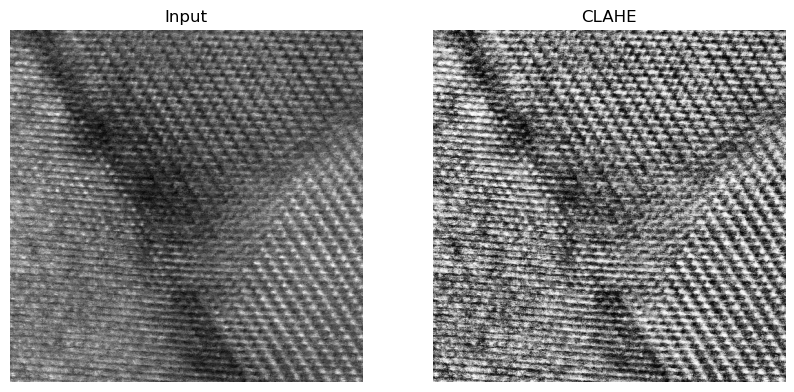

In [7]:
# Configure preview ROI (height, width). Set to None for full frame.
preview_roi = (512, 512)

# Identify if stack and the default z index
is_stack = (_preview_np.ndim == 3 and _preview_np.shape[-1] not in (3,4))
z_max = (_preview_np.shape[0]-1) if is_stack else 0

# Build widgets
w_kernel = W.IntSlider(value=64, min=8, max=256, step=8, description="kernel_size")
w_clip   = W.FloatLogSlider(value=0.01, base=10, min=-3, max=-0.5, step=0.05, description="clip_limit")
w_nbins  = W.IntSlider(value=256, min=64, max=4096, step=64, description="nbins")
w_z      = W.IntSlider(value=0, min=0, max=z_max, step=1, description="Z") if is_stack else None
w_gpu    = W.Checkbox(value=use_gpu, description="use_gpu")
w_pres   = W.Checkbox(value=preserve_dtype, description="preserve_dtype")
w_slice  = W.Checkbox(value=True, description="per_slice(3D)")
w_zchunk = W.IntSlider(value=64, min=1, max=256, step=1, description="z_chunk")

def _preview_show(*args):
    clear_output(wait=True)
    display(ui)

    img = _preview_np
    if is_stack:
        img = img[w_z.value]
    img = central_crop(img, preview_roi)

    # Run CLAHE
    if w_gpu.value and _GPU_OK:
        out = clahe_gpu(img, kernel_size=w_kernel.value, clip_limit=w_clip.value,
                        nbins=w_nbins.value, per_slice=True, z_chunk=w_zchunk.value,
                        preserve_dtype=w_pres.value)
    else:
        out = clahe_cpu(img, kernel_size=w_kernel.value, clip_limit=w_clip.value,
                        nbins=w_nbins.value, per_slice=True, preserve_dtype=w_pres.value)

    # Show before/after
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    if img.ndim == 2:
        axs[0].imshow(img, cmap='gray'); axs[0].set_title("Input")
        axs[1].imshow(out, cmap='gray'); axs[1].set_title("CLAHE")
    else:
        axs[0].imshow(img); axs[0].set_title("Input")
        axs[1].imshow(out); axs[1].set_title("CLAHE")
    for a in axs: a.axis('off')
    plt.show()

# Bind UI
controls = [w_kernel, w_clip, w_nbins, w_gpu, w_pres, w_slice, w_zchunk]
if w_z is not None: controls = [w_z] + controls
ui = W.VBox(controls)
for c in controls:
    c.observe(_preview_show, names='value')

display(ui)
_preview_show()


## Full-Dataset Processing

This cell applies the tuned parameters to **all files**, writing outputs to `OUT_DIR`.

**Tips for 3D stacks**
- Keep `per_slice=True` unless you specifically want 3D kernels.
- If you hit VRAM limits, **reduce `z_chunk`**.
- Outputs are saved as TIFF with `_clahe` suffix.

**Failure points (and likelihood)**
- Missing GPU libs → CPU fallback (low, ~10% if env is correct).
- VRAM OOM on very large stacks (moderate, ~40% for big Z if `z_chunk` too large).
- 3D non-(Z,Y,X) ordering (low, ~15% if data unusual) → adjust loader accordingly.


In [8]:
from tqdm import tqdm

# ---- Final parameters for batch run (set from preview results) ----
KERNEL_SIZE = 64
CLIP_LIMIT  = 0.01
NBINS       = 256
PER_SLICE   = True
Z_CHUNK     = 64
PRESERVE_DT = True
USE_GPU     = use_gpu  # can override True/False here

def save_tiff(path: Path, arr: np.ndarray, like: Optional[np.ndarray] = None):
    """Save as TIFF; copy basic dtype/shape; use BigTIFF when needed."""
    # Keep simple + robust options
    tiff.imwrite(
        str(path),
        arr,
        bigtiff=True if arr.nbytes > (2**32 - 1) else False,
        dtype=arr.dtype
    )

def process_file(in_path: Path, out_dir: Path):
    arr = read_any(in_path)  # CPU ndarray
    if USE_GPU and _GPU_OK:
        out = clahe_gpu(arr, kernel_size=KERNEL_SIZE, clip_limit=CLIP_LIMIT,
                        nbins=NBINS, per_slice=PER_SLICE, z_chunk=Z_CHUNK,
                        preserve_dtype=PRESERVE_DT)
    else:
        out = clahe_cpu(arr, kernel_size=KERNEL_SIZE, clip_limit=CLIP_LIMIT,
                        nbins=NBINS, per_slice=PER_SLICE, preserve_dtype=PRESERVE_DT)

    out_name = in_path.stem + "_clahe.tif"
    save_tiff(out_dir / out_name, out)
    # free memory between files
    del arr, out
    gc.collect()
    if _GPU_OK:
        cp._default_memory_pool.free_all_blocks()

# ---- Run ----
for fp in tqdm(file_list, desc="CLAHE batch"):
    process_file(fp, OUT_DIR)

print("Done. Wrote to:", OUT_DIR)


CLAHE batch: 100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  4.74it/s]

Done. Wrote to: /home/askiran/data/outputs/clahe


## GPU Memory Helper (optional)

Quick estimation of a safe `z_chunk` given your stack shape and dtype.

**Rule of thumb:** keep **working VRAM** under ~50–60% of *free* memory (tile histograms, bins, and buffers add overhead).


In [9]:
def recommend_z_chunk(shape: Sequence[int], dtype: np.dtype, free_gb: float | None = None,
                      headroom: float = 0.55) -> int:
    """
    Recommend a z_chunk for 3D (Z,Y,X) stacks.
    - headroom: fraction of free VRAM we allow the array+overheads to use.
    """
    if len(shape) != 3:
        raise ValueError("Expect shape as (Z, Y, X) for stacks.")
    Z, Y, X = shape
    bytes_per = np.dtype(dtype).itemsize
    # Working space ~ 2x input (float32 workspace + output) is a conservative baseline
    per_slice_bytes = (Y * X * bytes_per) + (Y * X * 4)  # input + float32 scratch
    # modest overhead for hist/buffers per tile (very rough)
    overhead = 16 * 1024 * 1024  # 16MB per chunk baseline
    if free_gb is None:
        free_gb = gpu_info()[1]
    if not free_gb or np.isnan(free_gb):
        free_gb = 8.0  # guess
    budget_bytes = free_gb * (1024**3) * headroom
    zc = max(1, int((budget_bytes - overhead) // per_slice_bytes))
    return max(1, min(Z, zc))

if _GPU_OK and _preview_np.ndim == 3 and _preview_np.shape[-1] not in (3,4):
    print("Recommended z_chunk:", recommend_z_chunk(_preview_np.shape, _preview_np.dtype))
else:
    print("z_chunk recommendation not applicable for this preview.")


z_chunk recommendation not applicable for this preview.


# Start from fresh code here --- 3D CLAHE on a Volume Built From 2D Slices (GPU-first with Chunked Halo)

**What this does**
- Loads a folder of 2D slices as a single 3D volume `(Z, Y, X)`.
- Applies **true 3D CLAHE** using cuCIM/CuPy (GPU) or scikit-image (CPU fallback).
- Supports **chunked processing with Z-overlap halos** to prevent boundary seams when VRAM is limited.
- Includes a **live preview UI** on a cropped sub-volume with adjustable parameters.

**Key parameters**
- `kernel_size_zyx`: CLAHE tile size (kz, ky, kx) in voxels.
- `clip_limit`: contrast limit (0–1).
- `nbins`: histogram bins (e.g., 256 for 8-bit, 1024–4096 for 16-bit).
- `z_chunk`: number of slices processed per chunk (core region).
- `halo`: extra slices on both sides to preserve context across chunk edges.

**Tips**
- Start with smaller `kernel_size_zyx` if fine details; larger values smooth more.
- If you see seams, **increase `halo`** (≈ `kernel_size_zyx[0]//2`) or reduce `z_chunk`.
- For 16-bit data, try `nbins=1024`–`2048`.


In [1]:
from __future__ import annotations
import os, re, gc, math
from pathlib import Path
from typing import Tuple, Sequence, Optional

import numpy as np
import tifffile as tiff
import matplotlib.pyplot as plt
import ipywidgets as W
from IPython.display import display, clear_output

# GPU first
try:
    import cupy as cp
    from cucim.skimage import exposure as csk_exposure
    _GPU_OK = True
except Exception:
    cp = None
    csk_exposure = None
    _GPU_OK = False

from skimage import exposure as sk_exposure  # CPU fallback

def gpu_info():
    if not _GPU_OK:
        return False, 0.0, 0.0
    try:
        free_b, total_b = cp.cuda.runtime.memGetInfo()
        return True, free_b/(1024**3), total_b/(1024**3)
    except Exception:
        return True, float('nan'), float('nan')

print("GPU available:", _GPU_OK, "| GPU mem (free/total GB):", gpu_info()[1:])


GPU available: True | GPU mem (free/total GB): (14.5166015625, 15.92047119140625)


## Paths & I/O

- Point `SLICE_DIR` to the **folder of 2D slices** (TIFF/PNG/JPG…).
- Filenames are **naturally sorted** (e.g., `slice_9` < `slice_10`).
- Output is a single **3D TIFF** with `_clahe3d` suffix.

In [2]:
BASE = Path("/home/askiran/data/")
SLICE_DIR = BASE / "0.6mm_close_middle"   # folder containing 2D slices for ONE volume
OUT_DIR   = BASE / "outputs" / "clahe3d"
OUT_DIR.mkdir(parents=True, exist_ok=True)

GLOB = "*.tif"   # or "*.png", "*.tif", etc.

def _natural_key(p: Path):
    return [int(s) if s.isdigit() else s.lower() for s in re.split(r"(\d+)", p.name)]

files = sorted(SLICE_DIR.glob(GLOB), key=_natural_key)
if not files:
    raise FileNotFoundError(f"No files matched {GLOB} in {SLICE_DIR}")

print(f"Found {len(files)} slices, e.g. {files[0].name} … {files[-1].name}")


Found 990 slices, e.g. 4. Bi-Zn_monotectic_high mag_0.6mm_0.5ups_recon0000.tif … 4. Bi-Zn_monotectic_high mag_0.6mm_0.5ups_recon0989.tif


## Loading the 3D Volume

- Reads all slices, checks consistent shape, stacks to `(Z, Y, X)`.
- Leaves dtype as-is (uint8/uint16/float).


In [3]:
def load_stack_from_folder(folder: Path, glob: str="*.tif") -> np.ndarray:
    paths = sorted(folder.glob(glob), key=_natural_key)
    if not paths:
        raise FileNotFoundError(f"No images in {folder} matching {glob}")

    first = tiff.imread(str(paths[0]))
    if first.ndim != 2:
        raise ValueError(f"Expect 2D slices; got shape {first.shape} in {paths[0].name}")

    Y, X = first.shape
    dtype = first.dtype
    vol = np.empty((len(paths), Y, X), dtype=dtype)
    vol[0] = first

    for i, p in enumerate(paths[1:], start=1):
        im = tiff.imread(str(p))
        if im.shape != (Y, X):
            raise ValueError(f"Inconsistent shape at {p.name}: {im.shape} vs {(Y,X)}")
        vol[i] = im
    return vol

vol_np = load_stack_from_folder(SLICE_DIR, GLOB)
print("Volume shape:", vol_np.shape, "dtype:", vol_np.dtype)


Volume shape: (990, 1014, 984) dtype: uint16


## 3D CLAHE Core — OOM-Safe (GPU/CPU) + Chunked Halo

- Adds **safe whole-volume check**; skips whole GPU if it likely won’t fit.
- On any GPU OOM, **flushes CuPy pools** before retrying.
- Provides **chunked+halo** kernel with low overhead and an **auto-shrink loop**.

**Params**
- `kernel_size_zyx`: (kz, ky, kx), e.g. (8, 64, 64)
- `clip_limit`: 0–1 (try 0.005–0.02)
- `nbins`: 256 (uint8) or 1024–2048 (uint16)
- `z_chunk`: slices per core chunk; auto-reduced on OOM
- `halo`: overlap in Z; start with `kz//2`
- `preserve_dtype`: True to cast back to original dtype

**Failure points (and likelihood)**
- GPU OOM even after shrinking `z_chunk` (low–moderate, ~25% on extremely large Z/YX)  
- Seams if `halo` too small (low, ~20%) → increase `halo` (≈ `kz//2` or more)
- Mismatched slice shapes (low, ~15%)



In [8]:
# --- OOM-safe 3D CLAHE core + helpers ---

# Robust CuPy OOM type (defined even if CuPy missing)
try:
    from cupy.cuda.memory import OutOfMemoryError as CuPyOOM
except Exception:
    class CuPyOOM(Exception): pass

def _to_float01(arr):
    odt = arr.dtype
    if np.issubdtype(odt, np.integer):
        scale = float(np.iinfo(odt).max)
        arrf = arr.astype(np.float32) / scale
    else:
        scale = None
        arrf = arr.astype(np.float32)
    return np.clip(arrf, 0.0, 1.0), scale, odt

def _restore_dtype(arrf01, scale, odt, preserve_dtype=True):
    if not preserve_dtype:
        return arrf01
    if np.issubdtype(odt, np.integer) and scale is not None:
        out = np.rint(arrf01 * scale)
        info = np.iinfo(odt)
        return np.clip(out, info.min, info.max).astype(odt)
    return arrf01.astype(odt)

def _ks_tuple(kernel_size_zyx, ndim=3):
    if isinstance(kernel_size_zyx, (tuple, list)):
        assert len(kernel_size_zyx) == ndim, f"kernel_size must have {ndim} dims"
        return tuple(int(x) for x in kernel_size_zyx)
    return (int(kernel_size_zyx),) * ndim

def free_gpu_memory():
    if not _GPU_OK:
        return
    try:
        cp.cuda.runtime.deviceSynchronize()
    except Exception:
        pass
    try:
        cp.get_default_memory_pool().free_all_blocks()
        cp.get_default_pinned_memory_pool().free_all_blocks()
    except Exception:
        pass

def approx_whole_bytes(shape, dtype):
    """Very rough upper bound for whole-volume GPU use (input + float32 workspace + out)."""
    Z, Y, X = shape
    item = np.dtype(dtype).itemsize
    vox = Z * Y * X
    # input + float32 scratch + output + histogram buffers fudge (~10%)
    return int(vox * (item + 4 + item) * 1.10)

def whole_fits_gpu(shape, dtype, headroom=0.55):
    if not _GPU_OK:
        return False
    _, free_gb, _ = gpu_info()
    if not np.isfinite(free_gb):
        return False
    need = approx_whole_bytes(shape, dtype)
    budget = int(free_gb * (1024**3) * headroom)
    return need <= budget

def clahe3d_gpu_whole(vol_np: np.ndarray,
                      kernel_size_zyx=(8,64,64),
                      clip_limit=0.01,
                      nbins=256,
                      preserve_dtype=True) -> np.ndarray:
    if not _GPU_OK:
        raise RuntimeError("GPU not available.")
    ks = _ks_tuple(kernel_size_zyx, 3)
    carr = cp.asarray(vol_np)
    carrf, scale, odt = _to_float01(carr)
    out = csk_exposure.equalize_adapthist(carrf, kernel_size=ks,
                                          clip_limit=clip_limit, nbins=nbins)
    out = cp.asnumpy(out)
    out = _restore_dtype(out, scale, odt, preserve_dtype)
    del carr, carrf
    free_gpu_memory()
    return out

def clahe3d_gpu_chunked(vol_np: np.ndarray,
                        kernel_size_zyx=(8,64,64),
                        clip_limit=0.01,
                        nbins=256,
                        z_chunk=64,
                        halo=4,
                        preserve_dtype=True) -> np.ndarray:
    if not _GPU_OK:
        raise RuntimeError("GPU not available.")
    Z, Y, X = vol_np.shape
    out_np = np.empty_like(vol_np) if preserve_dtype else np.empty(vol_np.shape, np.float32)
    ks = _ks_tuple(kernel_size_zyx, 3)

    beg = 0
    while beg < Z:
        core_end = min(beg + z_chunk, Z)
        start = max(0, beg - halo)
        end   = min(Z, core_end + halo)

        slab = cp.asarray(vol_np[start:end])            # (z, y, x)
        slabf, scale, odt = _to_float01(slab)
        slab_out = csk_exposure.equalize_adapthist(slabf, kernel_size=ks,
                                                   clip_limit=clip_limit, nbins=nbins)
        slab_out = _restore_dtype(cp.asnumpy(slab_out), scale, odt, preserve_dtype)
        core = slab_out[(beg - start):(core_end - start)]
        out_np[beg:core_end] = core

        # Cleanup per-iteration to keep VRAM steady
        del slab, slabf, slab_out, core
        free_gpu_memory()
        beg = core_end
    return out_np

def clahe3d_cpu(vol_np: np.ndarray,
                kernel_size_zyx=(8,64,64),
                clip_limit=0.01,
                nbins=256,
                preserve_dtype=True) -> np.ndarray:
    volf, scale, odt = _to_float01(vol_np)
    ks = _ks_tuple(kernel_size_zyx, 3)
    out = sk_exposure.equalize_adapthist(volf, kernel_size=ks,
                                         clip_limit=clip_limit, nbins=nbins)
    out = _restore_dtype(out, scale, odt, preserve_dtype)
    return out


## Preview (Interactive)

- Works on a **cropped sub-volume** for responsiveness.
- Shows **before/after** on an arbitrary slice with selectable orientation:
  - `axial (Z)`, `coronal (Y)`, `sagittal (X)`.
- Switch between **Whole** (no chunk) and **Chunked+Halo** modes to gauge seams/perf.


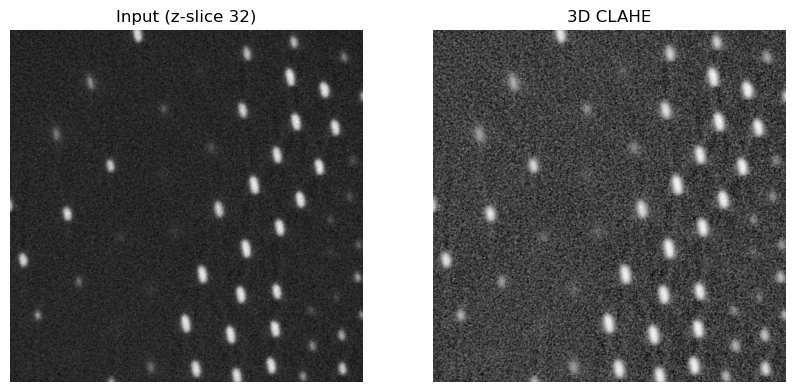

In [9]:
# Sub-volume crop for preview (z, y, x). Set any to 0/None to skip cropping on that axis.
preview_crop = (64, 512, 512)  # try reducing if slow

def center_crop_zyx(vol: np.ndarray, crop: Tuple[Optional[int], Optional[int], Optional[int]]):
    Z, Y, X = vol.shape
    cz, cy, cx = crop
    cz = min(cz or Z, Z); cy = min(cy or Y, Y); cx = min(cx or X, X)
    sz = (Z - cz)//2; sy = (Y - cy)//2; sx = (X - cx)//2
    return vol[sz:sz+cz, sy:sy+cy, sx:sx+cx]

vol_prev = center_crop_zyx(vol_np, preview_crop)

# Widgets
w_mode   = W.ToggleButtons(options=["Whole (GPU/CPU)", "Chunked+Halo (GPU)"], description="Mode")
w_kz     = W.IntSlider(value=8, min=3, max=31, step=1, description="kz")
w_ky     = W.IntSlider(value=64, min=8, max=256, step=8, description="ky")
w_kx     = W.IntSlider(value=64, min=8, max=256, step=8, description="kx")
w_clip   = W.FloatLogSlider(value=0.01, base=10, min=-3, max=-0.3, step=0.05, description="clip")
w_nbins  = W.IntSlider(value=256, min=64, max=4096, step=64, description="nbins")
w_zc     = W.IntSlider(value=32, min=4, max=max(4, vol_prev.shape[0]), step=2, description="z_chunk")
w_halo   = W.IntSlider(value=4, min=1, max=32, step=1, description="halo")
w_gpu    = W.Checkbox(value=_GPU_OK, description="use GPU")
w_pres   = W.Checkbox(value=True, description="preserve dtype")
w_orient = W.Dropdown(options=[("axial (Z)", "z"), ("coronal (Y)", "y"), ("sagittal (X)", "x")],
                      value="z", description="View")
w_idx    = W.IntSlider(value=vol_prev.shape[0]//2, min=0, max=vol_prev.shape[0]-1, step=1, description="Index")

def _slice_view(vol, orient, idx):
    if orient == "z":
        return vol[idx]
    elif orient == "y":
        return vol[:, idx, :]
    else:
        return vol[:, :, idx]

def _update(*args):
    clear_output(wait=True)
    display(ui)

    ks = (w_kz.value, w_ky.value, w_kx.value)

    if w_gpu.value and _GPU_OK:
        if w_mode.value.startswith("Whole"):
            try:
                out = clahe3d_gpu_whole(vol_prev, ks, w_clip.value, w_nbins.value, w_pres.value)
            except Exception as e:
                print("Whole-GPU failed, trying chunked:", e)
                out = clahe3d_gpu_chunked(vol_prev, ks, w_clip.value, w_nbins.value,
                                          z_chunk=w_zc.value, halo=w_halo.value,
                                          preserve_dtype=w_pres.value)
        else:
            out = clahe3d_gpu_chunked(vol_prev, ks, w_clip.value, w_nbins.value,
                                      z_chunk=w_zc.value, halo=w_halo.value,
                                      preserve_dtype=w_pres.value)
    else:
        out = clahe3d_cpu(vol_prev, ks, w_clip.value, w_nbins.value, w_pres.value)

    # Prepare slice for display
    idx = min(max(w_idx.value, 0), (vol_prev.shape[0]-1))
    sl_in  = _slice_view(vol_prev, w_orient.value, idx)
    sl_out = _slice_view(out,      w_orient.value, idx)

    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    axs[0].imshow(sl_in, cmap='gray');  axs[0].set_title(f"Input ({w_orient.value}-slice {idx})")
    axs[1].imshow(sl_out, cmap='gray'); axs[1].set_title("3D CLAHE")
    for a in axs: a.axis('off')
    plt.show()

controls = [w_mode, w_gpu, w_pres, w_kz, w_ky, w_kx, w_clip, w_nbins, w_zc, w_halo, w_orient, w_idx]
ui = W.VBox(controls)
for c in controls:
    c.observe(_update, names='value')

display(ui)
_update()


## z_chunk Recommender (updated) + Auto-Chooser

- Estimates a safe `z_chunk` from **current free VRAM**.
- New helper `auto_z_chunk` clamps to a range and adapts to dtype/shape.
- We’ll use this as a starting point for an adaptive “shrink on OOM” loop.


In [10]:
def recommend_z_chunk(shape: Sequence[int], dtype: np.dtype,
                      headroom=0.55) -> int:
    """Estimate z_chunk for 3D (Z,Y,X); assumes float32 workspace."""
    _, free_gb, _ = gpu_info()
    if not _GPU_OK or not np.isfinite(free_gb):
        free_gb = 8.0  # conservative fallback
    Z, Y, X = shape
    item = np.dtype(dtype).itemsize
    per_slice = (Y*X*item) + (Y*X*4)     # input + float32 scratch
    overhead = 32 * 1024 * 1024          # 32MB base overhead
    budget = free_gb * (1024**3) * headroom
    zc = int(max(1, (budget - overhead) // max(1, per_slice)))
    return max(4, min(Z, zc))

def auto_z_chunk(shape, dtype, target=None):
    if target is None or target <= 0:
        target = recommend_z_chunk(shape, dtype)
    # Clamp to a sane range
    return int(max(4, min(shape[0], target)))

print("Recommended z_chunk:", auto_z_chunk(vol_np.shape, vol_np.dtype))


Recommended z_chunk: 990


## OOM-Safe Runner

- Skips whole-volume GPU if the estimate says it won’t fit.
- If whole-volume is attempted and fails, **flush GPU memory** and switch to chunked.
- **Adaptive shrink loop** reduces `z_chunk` on each OOM until it fits; then proceeds.
- Final fallback: CPU.


In [11]:
def run_clahe3d_oom_safe(vol_np: np.ndarray,
                         kernel_size_zyx=(8,64,64),
                         clip_limit=0.01,
                         nbins=256,
                         preserve_dtype=True,
                         prefer_whole=True,
                         z_chunk=None,
                         halo=None,
                         min_z_chunk=4,
                         shrink_ratio=0.6):
    Z, Y, X = vol_np.shape
    if halo is None:
        halo = max(1, int(kernel_size_zyx[0] // 2))
    z_chunk = auto_z_chunk(vol_np.shape, vol_np.dtype, z_chunk)

    # 1) Optional whole-volume attempt (only if it looks safe)
    if prefer_whole and _GPU_OK and whole_fits_gpu(vol_np.shape, vol_np.dtype, headroom=0.55):
        try:
            print("[run] Trying whole-volume GPU...")
            return clahe3d_gpu_whole(vol_np, kernel_size_zyx, clip_limit, nbins, preserve_dtype)
        except CuPyOOM as e:
            print("[run] Whole GPU OOM:", e)
            free_gpu_memory()
        except Exception as e:
            print("[run] Whole GPU failed (non-OOM):", repr(e))
            free_gpu_memory()

    # 2) Chunked + halo with adaptive shrink on OOM
    if _GPU_OK:
        cur = int(z_chunk)
        while cur >= min_z_chunk:
            try:
                print(f"[run] Trying chunked GPU: z_chunk={cur}, halo={halo}")
                return clahe3d_gpu_chunked(vol_np, kernel_size_zyx, clip_limit, nbins,
                                           z_chunk=cur, halo=halo, preserve_dtype=preserve_dtype)
            except CuPyOOM as e:
                print(f"[run] OOM at z_chunk={cur}: {e}")
                free_gpu_memory()
                cur = max(min_z_chunk, int(cur * shrink_ratio))
            except Exception as e:
                print(f"[run] Chunked GPU failed at z_chunk={cur}:", repr(e))
                free_gpu_memory()
                break  # fall back to CPU

    # 3) CPU fallback
    print("[run] Falling back to CPU (may be slow).")
    return clahe3d_cpu(vol_np, kernel_size_zyx, clip_limit, nbins, preserve_dtype)


## Full 3D Processing (OOM-Safe)

Uses the **OOM-Safe Runner**:
- Prefers whole-volume if safe; otherwise chunked+halo with auto-shrink.
- Records the chosen `z_chunk`/`halo`.
- Saves BigTIFF when needed.


In [12]:
# === Final parameters (copy what worked in preview) ===
USE_GPU      = _GPU_OK               # leave True; runner will fall back automatically
KERNEL_ZYX   = (8, 64, 64)
CLIP_LIMIT   = 0.01
# Heuristic: choose nbins by dtype
NBINS        = 1024 if np.dtype(vol_np.dtype).itemsize >= 2 else 256
PRESERVE_DT  = True

# Optional hints for the runner
Z_CHUNK_HINT = None   # or set an integer to start from
HALO_HINT    = None   # defaults to kz//2

def save_volume_tiff(path: Path, vol: np.ndarray):
    tiff.imwrite(str(path), vol,
                 bigtiff=True if vol.nbytes > (2**32 - 1) else False,
                 dtype=vol.dtype)

# Run
out = run_clahe3d_oom_safe(vol_np,
                            kernel_size_zyx=KERNEL_ZYX,
                            clip_limit=CLIP_LIMIT,
                            nbins=NBINS,
                            preserve_dtype=PRESERVE_DT,
                            prefer_whole=USE_GPU,
                            z_chunk=Z_CHUNK_HINT,
                            halo=HALO_HINT,
                            min_z_chunk=4,
                            shrink_ratio=0.6)

save_path = (OUT_DIR / (SLICE_DIR.name.rstrip("/\\") + "_clahe3d.tif"))
save_volume_tiff(save_path, out)
del out
gc.collect()
free_gpu_memory()
print("Saved:", save_path)


[run] Trying chunked GPU: z_chunk=990, halo=4
[run] OOM at z_chunk=990: Out of memory allocating 4,734,976,000 bytes (allocated so far: 46,598,255,616 bytes).
[run] Trying chunked GPU: z_chunk=594, halo=4


KeyboardInterrupt: 

## Notes, Tuning & Troubleshooting

**Tuning**
- Start with `KERNEL_ZYX = (8,64,64)`. Increase `kz` to spread context along Z; increase `ky/kx` for larger XY tiles.
- If noise gets boosted, lower `CLIP_LIMIT` or increase `KERNEL_ZYX`.
- For 16-bit data: `NBINS=1024`–`2048` is usually sufficient.

**Perf & Memory**
- If whole-volume GPU fails, use the **chunked+halo** path with `Z_CHUNK = recommend_z_chunk(...)` and `HALO ≈ kz//2`.
- Free memory between steps: we already call `cp._default_memory_pool.free_all_blocks()`.

**Possible failure points**
- *OOM on GPU* (moderate, ~40% on very large volumes): reduce `Z_CHUNK` or `NBINS`, or smaller `KERNEL_ZYX`.
- *Seams between chunks* (low–moderate, ~30% if halo too small): increase `HALO` to at least `kz//2`.
- *Slice size mismatch* (low, ~15%): check all 2D slices have same `Y,X`.
- *Non-2D slices in folder* (low, ~10%): ensure no RGB/alpha images; adapt loader if needed.

**Extending**
- Multiple volumes? Put each volume’s slices in its **own subfolder** and loop over subfolders with the same pipeline.
